***Earnings Announcements and Volatility***

*Summary*:

How does volatility behave around earnings announcements? *Part one* of this project deals with the historical baseline volatility of stocks versus their behavior around earnings reports. The differences in these two volatilities are examined by examining S&P 500 stocks over the last year around their quarterly earnings reports, also conditioned on sector and VIX index. *Part two* of this project will use the same data, but consider the implied volatility of ATM options (from straddle options) with the behavior of the stock around around the earnings reports. This requires more historical data than is available on yfinance, so this is ongoing (perhaps CBOE or Polygon).





In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import pandas as pd
from datetime import datetime, timedelta
import requests
import warnings
warnings.filterwarnings('ignore')
import os

Historical Volatility Earnings Analysis

In [ ]:
# using historical volatility
class HistoricalVolEarningsAnalyzer:
    # constructor
    def __init__(self, lookback_days=365, vol_window=10):
        self.results = [] # future df
        self.sector_map = {} # dictionary to get sector from ticker
        self.lookback_days = lookback_days # days to look back for earnings
        self.vol_window = vol_window # days to compute historical volatility

    # get tickers with sectors
    def get_sp500_with_sectors(self, limit=None):
        try:
            # use requests to not get denied
            url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
            html = requests.get(url, headers={'User-Agent': 'Mozilla/5.0'}).text
            sp500 = pd.read_html(html)[0]
            sp500['Symbol'] = sp500['Symbol'].str.replace('.', '-', regex=False)
            self.sector_map = dict(zip(sp500['Symbol'], sp500['GICS Sector']))
            tickers = sp500['Symbol'].tolist()

            # prioritize liquid
            priority = ['AAPL','MSFT','GOOGL','AMZN','NVDA','META','TSLA','JPM','V','JNJ']
            tickers = sp500['Symbol'].tolist()
            priority = [t for t in priority if t in tickers]
            other = [t for t in tickers if t not in priority]

            return (priority + other)[:limit] if limit else priority + other
            
        except:
            # if wiki is broken/blocks
            self.sector_map = {
                'AAPL': 'Information Technology',
                'MSFT': 'Information Technology',
                'GOOGL': 'Communication Services',
                'NVDA': 'Information Technology',
                'META': 'Communication Services',
                'TSLA': 'Consumer Discretionary'
            }
            return list(self.sector_map.keys())

    # convert to tz-aware NY timestamps (yfinance throws exceptions otherwise)
    @staticmethod
    def ensure_nyse_timestamp(ts):
        ts = pd.Timestamp(ts)
        if ts.tzinfo is None:
            return ts.tz_localize('America/New_York', ambiguous='NaT', nonexistent='shift_forward')
        else:
            return ts.tz_convert('America/New_York')

    # get historical baseline volatility 
    def get_baseline_volatility(self, ticker, earnings_date, window=None):
        if window is None:
            window = self.vol_window
        try:
            earnings_date = self.ensure_nyse_timestamp(earnings_date)
            stock = yf.Ticker(ticker)

            # (look back window * 2) days to ensure enough trading days
            start_date = earnings_date - timedelta(days=window*2)
            end_date = earnings_date - timedelta(days=1)
            
            hist = stock.history(start=start_date, end=end_date)
            if hist.empty or len(hist) < 2:
                return None, None

            # calc returns
            hist['ret'] = hist['Close'].pct_change()
            hist = hist.dropna()
            if hist.empty:
                return None, None
            daily_vol = hist['ret'].std()
            stock_price = hist['Close'].iloc[-1]
            
            # sd as percentage
            baseline_vol_pct = daily_vol * 100 
            return baseline_vol_pct, stock_price
            
        except Exception as e:
            print(f"Error computing vol for {ticker}: {e}")
            return None, None

    # calc realized move (absolute)
    def calculate_realized_move(self, ticker, earnings_date):
        try:
            earnings_date = self.ensure_nyse_timestamp(earnings_date)
            stock = yf.Ticker(ticker)
            
            # fetch small window around date
            hist = stock.history(start = (earnings_date - timedelta(days=4)), end = (earnings_date + timedelta(days=4)))
            if len(hist) < 2: 
                return None, None
                
            # find where earnings date is and get neighboring prices
            idx = hist.index.get_indexer([earnings_date], method='nearest')[0]
            if idx < 1 or idx >= len(hist)-1: 
                return None, None
            pre_price = hist['Close'].iloc[idx-1]
            post_price = hist['Close'].iloc[idx+1]

            # calc return and move
            raw_return = (post_price - pre_price) / pre_price * 100
            abs_move = abs(raw_return)
            
            return abs_move, raw_return # Return both
            
        except:
            return None, None

    # calc VIX regime for volatility
    def get_vix_regime(self, date):
        try:
            date = self.ensure_nyse_timestamp(date)
            vix = yf.Ticker("^VIX")
            hist = vix.history(start = (date - timedelta(days=3)), end = (date + timedelta(days=1)))
            
            if not hist.empty:
                # decide the VIX level: low/med/high
                vix_level = hist['Close'].iloc[-1]
                if vix_level < 15:
                    return "Low", vix_level
                elif vix_level < 25:
                    return "Medium", vix_level
                else:
                    return "High", vix_level
        except:
            pass 
        return "Unknown", None

    # analyze one ticker
    def analyze_ticker(self, ticker, sector="Unknown"):
        try:
            stock = yf.Ticker(ticker)
            earnings = stock.earnings_dates
            if earnings is None or earnings.empty:
                return
         
            # filter earnings within lookback-now
            cutoff = datetime.now() - timedelta(days=self.lookback_days)
            cutoff = self.ensure_nyse_timestamp(cutoff)
            right_now = self.ensure_nyse_timestamp(datetime.now())
            recent_earnings = earnings[(earnings.index >= cutoff) & (earnings.index <= right_now)]
            if recent_earnings.empty:
                return
            print(f"Found {len(recent_earnings)} earnings for {ticker}")

            # analyze recent earnings events
            for earnings_date in recent_earnings.index:
                # get baseline vol
                baseline_vol, stock_price = self.get_baseline_volatility(ticker, earnings_date)
                if baseline_vol is None or baseline_vol == 0:
                    continue

                # get realized move around earnings
                realized_move, raw_return = self.calculate_realized_move(ticker, earnings_date)
                if realized_move is None:
                    continue

                # get VIX
                vix_regime, vix_level = self.get_vix_regime(earnings_date)

                # earnings multiplier - how much bigger was the move than normal?
                multiplier = realized_move / baseline_vol

                self.results.append({
                    'ticker': ticker,
                    'sector': sector,
                    'earnings_date': earnings_date.strftime('%Y-%m-%d'),
                    'stock_price': stock_price,
                    'baseline_vol_1d': baseline_vol,
                    'raw_return': raw_return,
                    'realized_move': realized_move,
                    'earnings_multiplier': multiplier,
                    'vix_regime': vix_regime
                })

                print(f"  Date: {earnings_date.strftime('%Y-%m-%d')} | "
                      f"Normal Vol: {baseline_vol:.1f}% | "
                      f"Realized: {realized_move:.1f}% | "
                      f"Multiplier: {multiplier:.1f}x")

        except Exception as e:
            print(f"Error analyzing {ticker}: {e}")

    # do the analysis
    def run_analysis(self, num_tickers):
        print("HISTORICAL VOLATILITY EARNINGS ANALYSIS")
        print(f"Analyzing earnings from past {self.lookback_days} days using historical stock volatility")

        tickers = self.get_sp500_with_sectors(limit=num_tickers)
        for i, ticker in enumerate(tickers, 1):
            sector = self.sector_map.get(ticker, "Unknown")
            print(f"[{i}/{len(tickers)}] {ticker} ({sector})")
            self.analyze_ticker(ticker, sector)
            print()

        return pd.DataFrame(self.results)
        
    # print out summary statistics
    def generate_report(self, df):
        if df.empty:
            return "No data collected."

        # update aggregation for new metric
        ticker_summary = df.groupby('ticker').agg({
            'sector': 'first',
            'baseline_vol_1d': 'mean',
            'realized_move': 'mean',
            'earnings_multiplier': 'mean',
            'earnings_date': 'count'
        }).rename(columns={'earnings_date':'count'}).round(2)
    
        summary_lines = ["\nPER-TICKER SUMMARY:"]
        summary_lines.append("Ticker | Count | Avg Normal Vol | Avg Realized | Avg Multiplier")
        for ticker, row in ticker_summary.iterrows():
            summary_lines.append(
                f"{ticker:<6} | {row['count']:<5} | "
                f"{row['baseline_vol_1d']:.2f}%         | {row['realized_move']:.2f}%       | {row['earnings_multiplier']:.2f}x"
            )
    
        overall_stats = f"""
    OVERALL STATISTICS:
    • Sample Size: {len(df)} earnings events
    • Avg Normal Daily Vol: {df['baseline_vol_1d'].mean():.2f}%
    • Avg Realized Earnings Move: {df['realized_move'].mean():.2f}%
    • Avg Earnings Multiplier: {df['earnings_multiplier'].mean():.2f}x
    
    Takeaway: On average, stocks in this list move {df['earnings_multiplier'].mean():.1f} times more 
    on earnings days than they do on a normal trading day.
    """
    
        return "\n".join(summary_lines) + "\n" + overall_stats

        
    # rank sectors by earnings multiplier
    def analyze_sector_impact(self, df):
        if df.empty:
            print("No data available for sector analysis.")
            return None
            
        sector_stats = df.groupby('sector').agg({
            'earnings_multiplier': ['mean', 'median', 'std', 'count'],
            'realized_move': 'mean'
        }).round(2)
        
        # flatten columns, sort by the mean multiplier
        sector_stats.columns = ['Avg_Multiplier', 'Median_Multiplier', 'Std_Dev', 'Sample_Size', 'Avg_Realized_Move']
        sector_stats = sector_stats.sort_values(by='Avg_Multiplier', ascending=False)
        
        print("SECTOR IMPACT RANKING (By Multiplier)")
        print(sector_stats)

        # top sector
        top_sector = sector_stats.index[0]
        top_val = sector_stats.iloc[0]['Avg_Multiplier']
        
        print(f"\nInsight: The {top_sector} sector shows the highest relative impact,")
        print(f"moving {top_val}x its normal daily range during earnings.")
        
        return sector_stats

    # generate bar chart ranking sectors multiplier
    def plot_sector_impact(self, df):
        if df.empty:
            print("No data to plot.")
            return

        sector_means = df.groupby('sector')['earnings_multiplier'].mean().sort_values(ascending=False)

        # plotting
        plt.figure(figsize=(12, 7))
        sns.set_theme(style="whitegrid")
        colors = sns.color_palette("viridis", len(sector_means))
        ax = sns.barplot(x=sector_means.values, y=sector_means.index, palette=colors)
        plt.axvline(x=1.0, color='red', linestyle='--', alpha=0.7, label='Normal Day Baseline')
        
        # labels
        plt.title('Average Earnings Volatility Multiplier by Sector', fontsize=16, pad=20)
        plt.xlabel('Multiplier (Realized Move / Normal Daily Vol)', fontsize=12)
        plt.ylabel('Sector', fontsize=12)
        plt.legend()
        
        # values on the bars
        for i, v in enumerate(sector_means.values):
            ax.text(v + 0.1, i, f"{v:.2f}x", color='black', va='center', fontweight='bold')

        plt.tight_layout()
        plt.show()

    # analyze how multiplier changes across VIX regimes
    def analyze_vix_regime(self, df):
        if df.empty:
            return "No data for VIX analysis."

        vix_stats = df.groupby('vix_regime').agg({
            'earnings_multiplier': ['mean', 'count'],
            'realized_move': 'mean',
            'baseline_vol_1d': 'mean'
        }).round(2)

        print("VIX REGIME PERFORMANCE")
        print(vix_stats)
        return vix_stats
        
    # create heatmap showing avg multiplier for sector vs VIX
    def plot_vix_interaction(self, df):
        if df.empty:
            return

        # pivot table for heatmap
        pivot = df.pivot_table(values='earnings_multiplier', index='sector', columns='vix_regime', aggfunc='mean')
        
        # sort regimes
        order = ['Low', 'Medium', 'High']
        existing_order = [o for o in order if o in pivot.columns]
        pivot = pivot[existing_order]

        # plot
        plt.figure(figsize=(10, 8))
        sns.heatmap(pivot, annot=True, cmap="YlGnBu", fmt=".2f", cbar_kws={'label': 'Avg Multiplier'})
        plt.title('Impact Heatmap: Sector x VIX Regime', fontsize=15)
        plt.xlabel('VIX Regime (Market Volatility Context)')
        plt.ylabel('Sector')
        plt.tight_layout()
        plt.show()

    # calculate probability of positive move and avg return per sector
    def analyze_directional_bias(self, df):
        if df.empty:
            return "No data for directional analysis."

        # create bool column for positive moves
        df['is_positive'] = df['raw_return'] > 0
        
        direction_stats = df.groupby('sector').agg({
            'raw_return': ['mean', 'median'],
            'is_positive': 'mean',
            'ticker': 'count'
        }).round(2)

        direction_stats.columns = ['Avg_Return', 'Median_Return', 'Win_Rate', 'Sample_Size']
        direction_stats = direction_stats.sort_values(by='Win_Rate', ascending=False)

        print("DIRECTIONAL BIAS BY SECTOR")
        print(direction_stats)
        return direction_stats

    # bar chart of percentage of positive earnings moves by sector
    def plot_directional_bias(self, df):
        if df.empty:
            return
        
        sector_win_rate = df.groupby('sector')['is_positive'].mean().sort_values() * 100

        # plot
        plt.figure(figsize=(10, 6))
        colors = ['#ff9999' if x < 50 else '#66b3ff' for x in sector_win_rate.values]
        ax = sector_win_rate.plot(kind='barh', color=colors)
        plt.axvline(x=50, color='black', linestyle='--', alpha=0.5)
        plt.title('Percent of Positive Earnings Moves by Sector', fontsize=14)
        plt.xlabel('Win Rate (%)')
        plt.xlim(0, 100)
        
        # annotate percentages
        for i, v in enumerate(sector_win_rate.values):
            ax.text(v + 1, i, f"{v:.1f}%", va='center', fontweight='bold')
            
        plt.tight_layout()
        plt.show()

    # save to CSV
    def export_results(self, df, sector_df=None, vix_df=None, direction_df=None, folder="earnings_exports"):
        # makedir
        if not os.path.exists(folder):
            os.makedirs(folder)
            
        timestamp = datetime.now().strftime("%Y%m%d_%H%M")
        
        # raw data
        raw_filename = f"{folder}/raw_earnings_data_{timestamp}.csv"
        df.to_csv(raw_filename, index=False)
        print(f"Saved Raw Data: {raw_filename}")

        # sector impact
        if sector_df is not None:
            sector_filename = f"{folder}/sector_impact_{timestamp}.csv"
            sector_df.to_csv(sector_filename)
            print(f"Saved Sector Analysis: {sector_filename}")

        # VIX analysis
        if vix_df is not None:
            vix_filename = f"{folder}/vix_regime_impact_{timestamp}.csv"
            vix_df.to_csv(vix_filename)
            print(f"Saved VIX Analysis: {vix_filename}")

        # directional bias
        if direction_df is not None:
            direction_filename = f"{folder}/directional_bias_{timestamp}.csv"
            direction_df.to_csv(direction_filename)
            print(f"Saved Directional Analysis: {direction_filename}")


In [16]:
analyzer = HistoricalVolEarningsAnalyzer(lookback_days=365, vol_window=10)
df = analyzer.run_analysis(500)

HISTORICAL VOLATILITY EARNINGS ANALYSIS
Analyzing earnings from past 365 days using historical stock volatility
[1/500] AAPL (Information Technology)
Found 4 earnings for AAPL
  Date: 2025-10-30 | Normal Vol: 1.4% | Realized: 0.9% | Multiplier: 0.6x
  Date: 2025-07-31 | Normal Vol: 0.7% | Realized: 2.0% | Multiplier: 2.9x
  Date: 2025-05-01 | Normal Vol: 2.0% | Realized: 6.8% | Multiplier: 3.4x
  Date: 2025-01-30 | Normal Vol: 2.3% | Realized: 4.0% | Multiplier: 1.8x

[2/500] MSFT (Information Technology)
Found 4 earnings for MSFT
  Date: 2025-10-29 | Normal Vol: 1.0% | Realized: 4.4% | Multiplier: 4.4x
  Date: 2025-07-30 | Normal Vol: 0.6% | Realized: 2.1% | Multiplier: 3.7x
  Date: 2025-04-30 | Normal Vol: 2.0% | Realized: 10.1% | Multiplier: 5.0x
  Date: 2025-01-29 | Normal Vol: 1.9% | Realized: 6.2% | Multiplier: 3.3x

[3/500] GOOGL (Communication Services)
Found 4 earnings for GOOGL
  Date: 2025-10-29 | Normal Vol: 1.8% | Realized: 2.4% | Multiplier: 1.3x
  Date: 2025-07-23 | Norm

$MRSH: possibly delisted; no price data found  (1d 2025-09-26 06:00:00-04:00 -> 2025-10-15 06:00:00-04:00) (Yahoo error = "Data doesn't exist for startDate = 1758880800, endDate = 1760522400")


Found 4 earnings for MRSH


$MRSH: possibly delisted; no price data found  (1d 2025-06-27 06:00:00-04:00 -> 2025-07-16 06:00:00-04:00) (Yahoo error = "Data doesn't exist for startDate = 1751018400, endDate = 1752660000")
$MRSH: possibly delisted; no price data found  (1d 2025-03-28 07:00:00-04:00 -> 2025-04-16 07:00:00-04:00) (Yahoo error = "Data doesn't exist for startDate = 1743159600, endDate = 1744801200")
$MRSH: possibly delisted; no price data found  (1d 2025-01-10 07:00:00-05:00 -> 2025-01-29 07:00:00-05:00) (Yahoo error = "Data doesn't exist for startDate = 1736510400, endDate = 1738152000")



[306/500] MLM (Materials)
Found 4 earnings for MLM
  Date: 2025-11-04 | Normal Vol: 0.9% | Realized: 1.4% | Multiplier: 1.6x
  Date: 2025-08-07 | Normal Vol: 1.4% | Realized: 2.2% | Multiplier: 1.5x
  Date: 2025-04-30 | Normal Vol: 1.7% | Realized: 3.6% | Multiplier: 2.0x
  Date: 2025-02-12 | Normal Vol: 0.9% | Realized: 0.5% | Multiplier: 0.6x

[307/500] MAS (Industrials)
Found 4 earnings for MAS
  Date: 2025-10-29 | Normal Vol: 1.9% | Realized: 5.0% | Multiplier: 2.7x
  Date: 2025-07-31 | Normal Vol: 1.3% | Realized: 4.7% | Multiplier: 3.6x
  Date: 2025-04-23 | Normal Vol: 3.5% | Realized: 1.8% | Multiplier: 0.5x
  Date: 2025-02-11 | Normal Vol: 1.6% | Realized: 1.1% | Multiplier: 0.7x

[308/500] MA (Financials)
Found 4 earnings for MA
  Date: 2025-10-30 | Normal Vol: 1.2% | Realized: 0.5% | Multiplier: 0.4x
  Date: 2025-07-31 | Normal Vol: 0.6% | Realized: 0.1% | Multiplier: 0.2x
  Date: 2025-05-01 | Normal Vol: 1.3% | Realized: 2.1% | Multiplier: 1.6x
  Date: 2025-01-30 | Normal V


PER-TICKER SUMMARY:
Ticker | Count | Avg Normal Vol | Avg Realized | Avg Multiplier
A      | 4     | 1.93%         | 3.05%       | 2.11x
AAPL   | 4     | 1.59%         | 3.42%       | 2.17x
ABBV   | 4     | 1.64%         | 6.28%       | 4.86x
ABNB   | 3     | 1.63%         | 2.75%       | 1.58x
ABT    | 4     | 1.18%         | 4.80%       | 5.03x
ACGL   | 4     | 1.53%         | 1.65%       | 1.06x
ACN    | 4     | 1.40%         | 2.55%       | 2.02x
ADBE   | 4     | 1.57%         | 4.44%       | 3.09x
ADI    | 4     | 1.91%         | 7.73%       | 4.28x
ADM    | 4     | 1.40%         | 4.66%       | 3.33x
ADP    | 4     | 0.91%         | 2.35%       | 3.65x
ADSK   | 2     | 1.39%         | 3.34%       | 2.40x
AEE    | 3     | 0.99%         | 2.31%       | 2.73x
AEP    | 4     | 1.20%         | 2.51%       | 3.44x
AES    | 4     | 1.93%         | 5.00%       | 2.79x
AFL    | 4     | 1.22%         | 3.56%       | 3.03x
AIG    | 4     | 1.36%         | 2.50%       | 1.74x
AIZ    | 4    

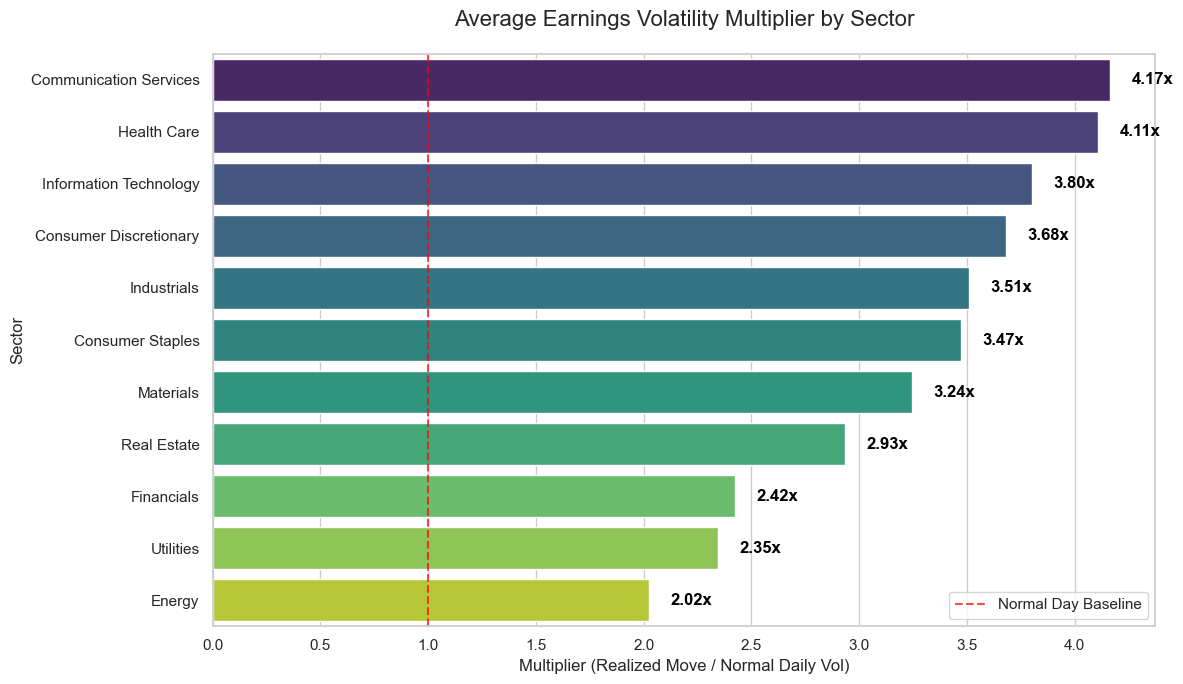

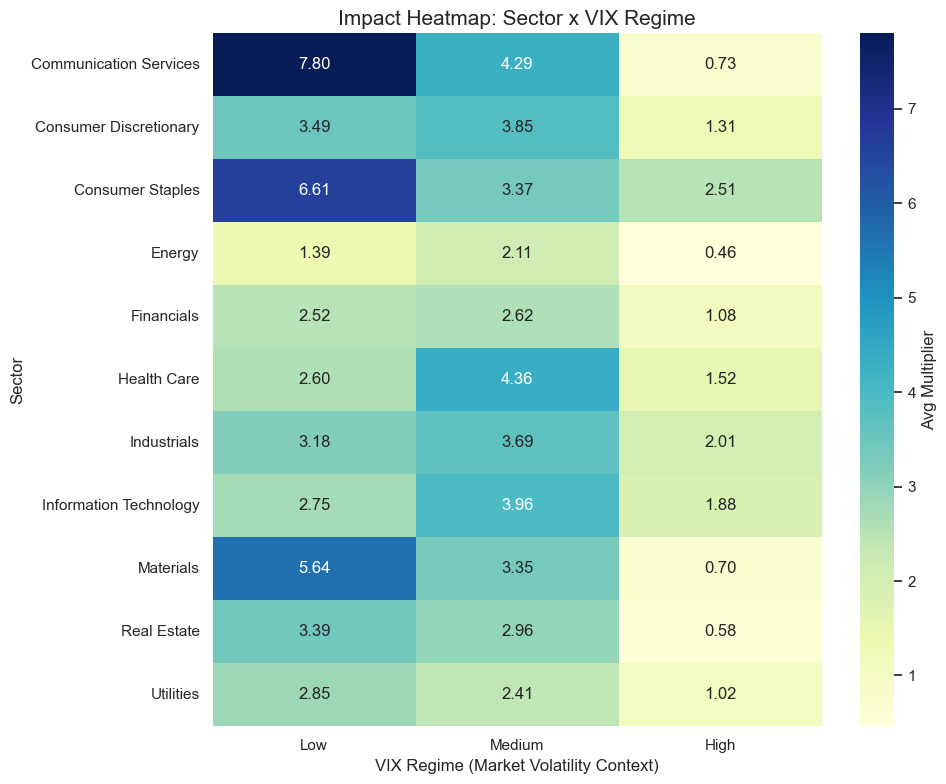

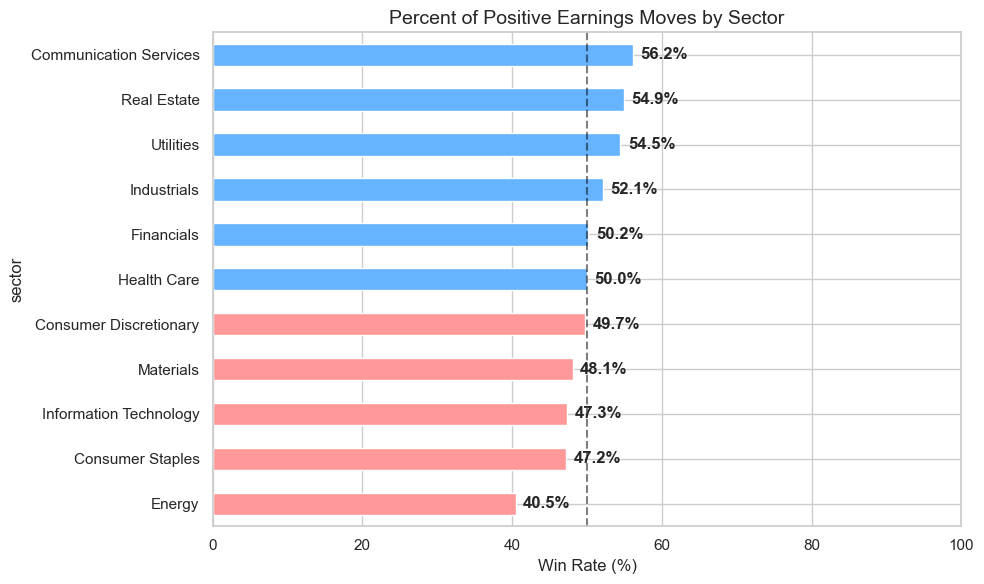

In [17]:
print(analyzer.generate_report(df))

sector_stats = analyzer.analyze_sector_impact(df)
vix_stats = analyzer.analyze_vix_regime(df)
direction_stats = analyzer.analyze_directional_bias(df)

analyzer.export_results(df, sector_stats, vix_stats, direction_stats)

analyzer.plot_sector_impact(df)
analyzer.plot_vix_interaction(df)
analyzer.plot_directional_bias(df)

Implied Volatility Earnings Analysis

In [22]:
# need to fix this with proper API
class EarningsVolatilityAnalyzer:

    @staticmethod
    def ensure_nyse_timestamp(ts):
        ts = pd.Timestamp(ts)
        if ts.tzinfo is None:
            return ts.tz_localize('America/New_York', ambiguous='NaT', nonexistent='shift_forward')
        else:
            return ts.tz_convert('America/New_York')
            
    def __init__(self, lookback_days=365):
        self.lookback_days = lookback_days
        self.results = []
        self.skipped_events = []  # log skipped events
        self.sector_map = {}
        self.ticker_map = {}

    def get_sp500_tickers(self, limit=None):
        try:
            url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
            html = requests.get(url, headers={'User-Agent': 'Mozilla/5.0'}).text
            sp500 = pd.read_html(html)[0]
            sp500['Symbol'] = sp500['Symbol'].str.replace('.', '-', regex=False)
            self.sector_map = dict(zip(sp500['Symbol'], sp500['GICS Sector']))
            tickers = sp500['Symbol'].tolist()
            return tickers[:limit] if limit else tickers
        except Exception as e:
            print(f"Error fetching S&P 500 list, using fallback tickers: {e}")
        
            self.sector_map = {
                'AAPL': 'Information Technology',
                'MSFT': 'Information Technology', 
                'GOOGL': 'Communication Services',
                'AMZN': 'Consumer Discretionary',
                'NVDA': 'Information Technology',
                'META': 'Communication Services',
                'TSLA': 'Consumer Discretionary',
                'JPM': 'Financials'
            }
            return list(self.sector_map.keys())

    def get_earnings_dates(self, ticker, start_date):
        try:
            ticker_to_use = self.ticker_map.get(ticker, ticker)
            stock = yf.Ticker(ticker_to_use)
            earnings = stock.earnings_dates
            if earnings is None or earnings.empty:
                self.skipped_events.append({'ticker': ticker, 'reason': 'No earnings data'})
                return []

            start_date = self.ensure_nyse_timestamp(start_date)
            today = self.ensure_nyse_timestamp(datetime.now())
            earnings = earnings[earnings.index >= start_date]

            # skip future earnings
            earnings = earnings[earnings.index <= today]
            if earnings.empty:
                self.skipped_events.append({'ticker': ticker, 'reason': 'No earnings in past'})
                return []

            return earnings.index.tolist()
        except Exception as e:
            print(f"Error fetching earnings for {ticker}: {e}")
            self.skipped_events.append({'ticker': ticker, 'reason': f'Error fetching earnings: {e}'})
            return []

    # need better data
    def calculate_implied_move_from_straddle(self, ticker, earnings_date):
        try:
            earnings_date = self.ensure_nyse_timestamp(earnings_date)
            ticker_to_use = self.ticker_map.get(ticker, ticker)
            stock = yf.Ticker(ticker_to_use)

            hist = stock.history(start=(earnings_date - timedelta(days=5)),
                                 end=(earnings_date + timedelta(days=1)))
            if hist.empty:
                self.skipped_events.append({'ticker': ticker, 'earnings_date': earnings_date, 'reason': 'No stock history'})
                return None, None
            stock_price = hist['Close'].iloc[-1]

            options_dates = stock.options
            if not options_dates:
                self.skipped_events.append({'ticker': ticker, 'earnings_date': earnings_date, 'reason': 'No options chain'})
                return None, None

            valid_expirations = [d for d in options_dates if pd.to_datetime(d) >= earnings_date]
            if not valid_expirations:
                self.skipped_events.append({'ticker': ticker, 'earnings_date': earnings_date, 'reason': 'No options expirations after earnings'})
                return None, None
            exp_date = valid_expirations[0]

            chain = stock.option_chain(exp_date)
            calls, puts = chain.calls, chain.puts
            if calls.empty or puts.empty:
                self.skipped_events.append({'ticker': ticker, 'earnings_date': earnings_date, 'reason': 'Empty options chain'})
                return None, None

            calls['strike_diff'] = abs(calls['strike'] - stock_price)
            puts['strike_diff'] = abs(puts['strike'] - stock_price)
            atm_call = calls.loc[calls['strike_diff'].idxmin()]
            atm_put = puts.loc[puts['strike_diff'].idxmin()]

            if pd.isna(atm_call['bid']) or pd.isna(atm_call['ask']) or \
               pd.isna(atm_put['bid']) or pd.isna(atm_put['ask']):
                self.skipped_events.append({'ticker': ticker, 'earnings_date': earnings_date, 'reason': 'Missing bid/ask'})
                return None, None

            call_price = (atm_call['bid'] + atm_call['ask']) / 2
            put_price = (atm_put['bid'] + atm_put['ask']) / 2
            straddle_price = call_price + put_price
            implied_move = (straddle_price / stock_price) * 100

            return implied_move, stock_price
        except Exception as e:
            self.skipped_events.append({'ticker': ticker, 'earnings_date': earnings_date, 'reason': f'Error calculating implied move: {e}'})
            return None, None

    def calculate_realized_move(self, ticker, earnings_date):
        try:
            earnings_date = self.ensure_nyse_timestamp(earnings_date)
            ticker_to_use = self.ticker_map.get(ticker, ticker)
            stock = yf.Ticker(ticker_to_use)
            hist = stock.history(start=(earnings_date - timedelta(days=5)),
                                 end=(earnings_date + timedelta(days=5)))
            if len(hist) < 2:
                self.skipped_events.append({'ticker': ticker, 'earnings_date': earnings_date, 'reason': 'Insufficient stock history'})
                return None, None

            idx_array = hist.index.get_indexer([earnings_date], method='nearest')
            if len(idx_array) == 0:
                return None, None
            idx = idx_array[0]
            if idx < 1 or idx + 1 >= len(hist):
                return None, None

            pre_price = hist['Close'].iloc[idx - 1]
            post_price = hist['Close'].iloc[idx + 1]
            realized_move = abs((post_price - pre_price) / pre_price) * 100
            return realized_move, pre_price
        except Exception as e:
            self.skipped_events.append({'ticker': ticker, 'earnings_date': earnings_date, 'reason': f'Error calculating realized move: {e}'})
            return None, None

    def get_vix_regime(self, date):
        try:
            date = self.ensure_nyse_timestamp(date)
            vix = yf.Ticker("^VIX")
            hist = vix.history(start=(date - timedelta(days=5)), end=(date + timedelta(days=1)))
            if hist.empty:
                return "Unknown"
            level = hist['Close'].iloc[-1]
            if level < 15:
                return "Low"
            elif level < 25:
                return "Medium"
            else:
                return "High"
        except:
            return "Unknown"

    def analyze_ticker(self, ticker, sector="Unknown"):
        start_date = self.ensure_nyse_timestamp(datetime.now() - timedelta(days=self.lookback_days))
        earnings_dates = self.get_earnings_dates(ticker, start_date)
        if not earnings_dates:
            return

        print(f"Analyzing {ticker}: found {len(earnings_dates)} earnings dates")

        for edate in earnings_dates[:4]:
            implied_move, stock_price = self.calculate_implied_move_from_straddle(ticker, edate)
            if implied_move is None:
                continue
            realized_move, _ = self.calculate_realized_move(ticker, edate)
            if realized_move is None:
                continue
            vix_regime = self.get_vix_regime(edate)

            self.results.append({
                'ticker': ticker,
                'sector': sector,
                'earnings_date': edate,
                'stock_price': stock_price,
                'implied_move': implied_move,
                'realized_move': realized_move,
                'iv_overpricing': implied_move - realized_move,
                'vix_regime': vix_regime
            })

    def run_analysis(self, num_tickers=50):
        tickers = self.get_sp500_tickers(limit=num_tickers)
        if not tickers:
            print("No tickers to analyze")
            return pd.DataFrame()

        for ticker in tickers:
            sector = self.sector_map.get(ticker, "Unknown")
            try:
                self.analyze_ticker(ticker, sector)
            except Exception as e:
                print(f"Skipping {ticker} due to error: {e}")
                continue

        if not self.results:
            print("No results collected. Check tickers or data availability.")
            return pd.DataFrame()

        return pd.DataFrame(self.results)

    # summary stats
    def generate_summary_stats(self, df):
        if df.empty:
            return "No data collected"
        summary = f"""
Sample Size: {len(df)} earnings events across {df['ticker'].nunique()} stocks
Average Implied Move: {df['implied_move'].mean():.2f}%
Average Realized Move: {df['realized_move'].mean():.2f}%
Average IV Overpricing: {df['iv_overpricing'].mean():.2f}%
Median IV Overpricing: {df['iv_overpricing'].median():.2f}%
Takeaway:
Options market overprices earnings moves by an average of {df['iv_overpricing'].mean():.2f}%. This is
most pronounced in {df.groupby('sector')['iv_overpricing'].mean().idxmax()} sector
and during {df.groupby('vix_regime')['iv_overpricing'].mean().idxmax()} VIX regimes.
"""
        return summary
        
    def get_sector_comparison(self, df):
        if df.empty or 'sector' not in df.columns:
            return None
        
        sector_stats = df.groupby('sector').agg({
            'iv_overpricing': ['mean', 'std', 'count'],
            'implied_move': 'mean',
            'realized_move': 'mean'
        }).round(2)
        
        # at least 3 observations
        sector_stats = sector_stats[sector_stats[('iv_overpricing', 'count')] >= 3]
        
        return sector_stats

    def analyze_vix_interaction(self, df):
        if df.empty:
            return None
        
        # cross-tab of sector vs VIX regime
        pivot = df.pivot_table(values='iv_overpricing', index='sector', columns='vix_regime', aggfunc=['mean', 'count']).round(2)
        
        return pivot



In [23]:
analyzer = EarningsVolatilityAnalyzer(lookback_days=30)

# watch rate limit !
print("Starting earnings volatility analysis...")

# run on small sample first
results_df = analyzer.run_analysis(num_tickers=10)

if not results_df.empty:
    print("\n" + analyzer.generate_summary_stats(results_df))
    
    print("SECTOR DEEP DIVE")
    sector_stats = analyzer.plot_sector_comparison(results_df)
    if sector_stats is not None:
        print("\nDetailed Sector Statistics:")
        print(sector_stats)

    vix_sector = analyzer.analyze_vix_interaction(results_df)
    if vix_sector is not None:
        print("\n\nSector Performance by VIX Regime:")
        print(vix_sector)

else:
    print("No results collected. Check data availability.")

Starting earnings volatility analysis...


FB: No earnings dates found, symbol may be delisted


Analyzing JPM: found 1 earnings dates
No results collected. Check tickers or data availability.
No results collected. Check data availability.
